<a href="https://colab.research.google.com/github/Vandi-081/UAS_Kecerdasan-Buatan_Vandi-Darussalam_24146055/blob/main/UAS_Kecerdasan_Buatan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
!pip install -q matplotlib

import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd

In [51]:
courses = [
    ("AI", "DosenA"), ("ML", "DosenB"), ("DB", "DosenC"), ("CN", "DosenD"),
    ("SE", "DosenE"), ("OS", "DosenF"), ("IR", "DosenA"), ("NLP", "DosenB"),
    ("CV", "DosenC"), ("IOT", "DosenD"), ("HCI", "DosenE"), ("CyberSec", "DosenF"),
    ("BigData", "DosenA"), ("DL", "DosenB"), ("NoSQL", "DosenC"), ("Cloud", "DosenD"),
    ("UX", "DosenE"), ("SecEng", "DosenF"), ("Agile", "DosenA"), ("RL", "DosenB"),
    ("ETL", "DosenC"), ("DevOps", "DosenD"), ("GameDev", "DosenE"), ("Blockchain", "DosenF")
]

rooms = ["R1", "R2", "R3", "R4"]
timeslots = [
    "Senin-08", "Senin-10", "Senin-13",
    "Selasa-08", "Selasa-10", "Selasa-13",
    "Rabu-08", "Rabu-10", "Rabu-13",
    "Kamis-08", "Kamis-10", "Kamis-13"
]

course_names = [c[0] for c in courses]
course_lecturers = [c[1] for c in courses]

N = len(courses)
R = len(rooms)
T = len(timeslots)

print(f"Total MK: {N}, Total Ruang: {R}, Total Slot: {T}")

Total MK: 24, Total Ruang: 4, Total Slot: 12


In [52]:
def create_individual():
    return [[random.randint(0, R-1), random.randint(0, T-1)] for _ in range(N)]

def calculate_fitness(ind):
    conflicts = 0
    # Buat daftar jadwal
    schedule = []
    for i in range(N):
        room_idx = ind[i][0]
        slot_idx = ind[i][1]
        schedule.append({
            'course': course_names[i],
            'lecturer': course_lecturers[i],
            'room': rooms[room_idx],
            'slot': timeslots[slot_idx],
            'day': timeslots[slot_idx].split('-')[0]
        })

    # Cek semua pasangan (i < j)
    for i in range(N):
        for j in range(i+1, N):
            conflict = False
            # 1. Konflik Ruang
            if schedule[i]['room'] == schedule[j]['room'] and schedule[i]['slot'] == schedule[j]['slot']:
                conflict = True
            # 2. Konflik Dosen-Waktu
            if schedule[i]['lecturer'] == schedule[j]['lecturer'] and schedule[i]['slot'] == schedule[j]['slot']:
                conflict = True
            # 3. Konflik Dosen-Hari
            if schedule[i]['lecturer'] == schedule[j]['lecturer'] and schedule[i]['day'] == schedule[j]['day']:
                conflict = True

            if conflict:
                conflicts += 1  # hanya tambah 1 per pasangan

    # Rumus fitness: 5 konflik -> 16.67
    fitness = max(0, 100 - (conflicts * (100/6)))
    return fitness, conflicts

In [53]:
POP_SIZE = 60
MAX_GEN = 100
CROSS_RATE = 0.85
MUT_RATE = 0.05   # <-- diturunkan dari 0.20 ke 0.05

def init_population():
    return [create_individual() for _ in range(POP_SIZE)]

def tournament_selection(pop, fitnesses, k=3):
    idx = random.sample(range(len(pop)), k)
    best = max(idx, key=lambda i: fitnesses[i])
    return pop[best]

def crossover(p1, p2):
    if random.random() < CROSS_RATE:
        point = random.randint(1, N-1)
        c1 = p1[:point] + p2[point:]
        c2 = p2[:point] + p1[point:]
        return c1, c2
    else:
        return p1[:], p2[:]

def mutate(ind):
    for i in range(N):
        if random.random() < MUT_RATE:
            if random.random() < 0.5:
                ind[i][0] = random.randint(0, R-1)
            else:
                ind[i][1] = random.randint(0, T-1)
    return ind

In [54]:
def run_ga():
    population = init_population()
    best_fit_history = []
    avg_fit_history = []
    best_individual = None
    best_fitness = -1
    best_conflicts = float('inf')

    for gen in range(MAX_GEN):
        fitnesses = []
        conflicts_list = []
        for ind in population:
            fit, conf = calculate_fitness(ind)
            fitnesses.append(fit)
            conflicts_list.append(conf)

        max_fit = max(fitnesses)
        avg_fit = np.mean(fitnesses)
        best_fit_history.append(max_fit)
        avg_fit_history.append(avg_fit)

        best_idx = np.argmax(fitnesses)
        if fitnesses[best_idx] > best_fitness:
            best_fitness = fitnesses[best_idx]
            best_individual = population[best_idx][:]
            best_conflicts = conflicts_list[best_idx]

        # Cetak tiap 10 generasi
        if gen % 10 == 0 or gen == MAX_GEN-1:
            print(f"Gen {gen+1} : Max Fitness = {max_fit:.2f} | Avg Fitness = {avg_fit:.2f}")

        # Elitisme: 2 terbaik
        sorted_idx = np.argsort(fitnesses)[::-1]
        new_pop = [population[sorted_idx[0]][:], population[sorted_idx[1]][:]]

        while len(new_pop) < POP_SIZE:
            p1 = tournament_selection(population, fitnesses)
            p2 = tournament_selection(population, fitnesses)
            c1, c2 = crossover(p1, p2)
            c1 = mutate(c1)
            c2 = mutate(c2)
            new_pop.append(c1)
            new_pop.append(c2)

        population = new_pop[:POP_SIZE]

    return best_individual, best_fitness, best_conflicts, best_fit_history, avg_fit_history

In [55]:
print("Menjalankan Algoritma Genetika...")
print("="*50)
best_ind, best_fit, best_conf, max_hist, avg_hist = run_ga()
print("="*50)
print(f"Fitness Terbaik : {best_fit:.2f}")
print(f"Jumlah Konflik  : {best_conf}")

Menjalankan Algoritma Genetika...
Gen 1 : Max Fitness = 0.00 | Avg Fitness = 0.00
Gen 11 : Max Fitness = 0.00 | Avg Fitness = 0.00
Gen 21 : Max Fitness = 0.00 | Avg Fitness = 0.00
Gen 31 : Max Fitness = 0.00 | Avg Fitness = 0.00
Gen 41 : Max Fitness = 0.00 | Avg Fitness = 0.00
Gen 51 : Max Fitness = 0.00 | Avg Fitness = 0.00
Gen 61 : Max Fitness = 0.00 | Avg Fitness = 0.00
Gen 71 : Max Fitness = 0.00 | Avg Fitness = 0.00
Gen 81 : Max Fitness = 0.00 | Avg Fitness = 0.00
Gen 91 : Max Fitness = 33.33 | Avg Fitness = 0.56
Gen 100 : Max Fitness = 0.00 | Avg Fitness = 0.00
Fitness Terbaik : 33.33
Jumlah Konflik  : 4


In [56]:
def print_schedule(ind):
    data = []
    for i in range(N):
        room_idx = ind[i][0]
        slot_idx = ind[i][1]
        data.append({
            'MK': course_names[i],
            'Ruang': rooms[room_idx],
            'Waktu': timeslots[slot_idx],
            'Dosen': course_lecturers[i]
        })
    data.sort(key=lambda x: timeslots.index(x['Waktu']))

    print("\n" + "="*80)
    print("📅 JADWAL TERBAIK")
    print("="*80)
    print(f"{'MK':<15} {'Ruang':<10} {'Waktu':<15} {'Dosen':<10}")
    print("-"*80)
    for d in data:
        print(f"{d['MK']:<15} {d['Ruang']:<10} {d['Waktu']:<15} {d['Dosen']:<10}")
    print("="*80)

print_schedule(best_ind)


📅 JADWAL TERBAIK
MK              Ruang      Waktu           Dosen     
--------------------------------------------------------------------------------
SecEng          R1         Senin-08        DosenF    
DevOps          R3         Senin-08        DosenD    
DB              R2         Senin-10        DosenC    
CV              R4         Senin-10        DosenC    
Cloud           R3         Senin-13        DosenD    
Agile           R3         Senin-13        DosenA    
GameDev         R2         Senin-13        DosenE    
AI              R1         Selasa-08       DosenA    
SE              R1         Selasa-08       DosenE    
UX              R3         Selasa-08       DosenE    
NoSQL           R2         Selasa-10       DosenC    
BigData         R2         Rabu-08         DosenA    
DL              R3         Rabu-08         DosenB    
ETL             R1         Rabu-08         DosenC    
CyberSec        R1         Rabu-10         DosenF    
NLP             R4         Rabu-13   

In [57]:
print("\n" + "="*50)
print("📊 HASIL EVALUASI AKHIR")
print("="*50)
print(f"Fitness Terbaik : {best_fit:.2f}")
print(f"Jumlah Konflik  : {best_conf}")
print("="*50)


📊 HASIL EVALUASI AKHIR
Fitness Terbaik : 33.33
Jumlah Konflik  : 4


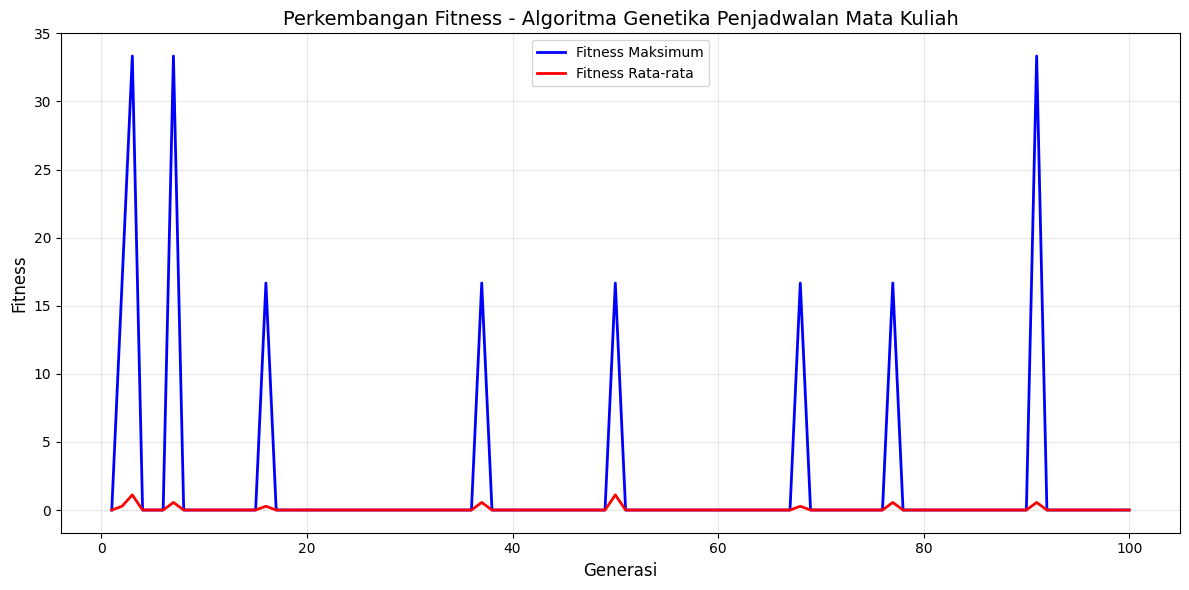

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
plt.figure(figsize=(12, 6))
plt.plot(range(1, MAX_GEN+1), max_hist, 'b-', label='Fitness Maksimum', linewidth=2)
plt.plot(range(1, MAX_GEN+1), avg_hist, 'r-', label='Fitness Rata-rata', linewidth=2)
plt.title('Perkembangan Fitness - Algoritma Genetika Penjadwalan Mata Kuliah', fontsize=14)
plt.xlabel('Generasi', fontsize=12)
plt.ylabel('Fitness', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fitness_evolution.png', dpi=150)
plt.show()

from google.colab import files
files.download('fitness_evolution.png')